# Chapter 06 - Statistical Machine Learning

## Objectives
Understand supervised machine learning methods that combine statistics and algorithms for prediction. Covers KNN, trees, bagging, random forest, boosting, and feature importance.

## Core Theory
Machine learning emphasizes predictive performance. Statistical ML balances interpretability, generalization, and uncertainty.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
sns.set_theme(style='whitegrid')
np.random.seed(42)

In [2]:
X,y=make_classification(n_samples=900,n_features=6,n_informative=4,n_redundant=0,
weights=[0.6,0.4],random_state=42)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

## 1. K-Nearest Neighbors (KNN)
Predicts class based on nearest observations. Sensitive to scaling.

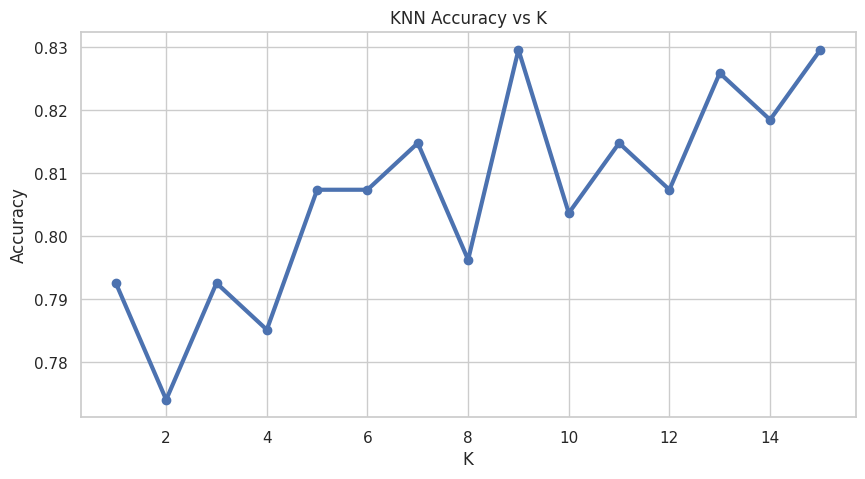

In [3]:
ks=range(1,16)
scores=[]
for k in ks:
    knn=make_pipeline(StandardScaler(),KNeighborsClassifier(n_neighbors=k))
    knn.fit(X_train,y_train)
    scores.append(accuracy_score(y_test,knn.predict(X_test)))
plt.figure(figsize=(10,5))
plt.plot(list(ks),scores,marker='o',lw=3)
plt.title('KNN Accuracy vs K')
plt.xlabel('K'); plt.ylabel('Accuracy')
plt.show()

## 2. Decision Tree
Creates recursive if-then splits. Easy to explain but can overfit.

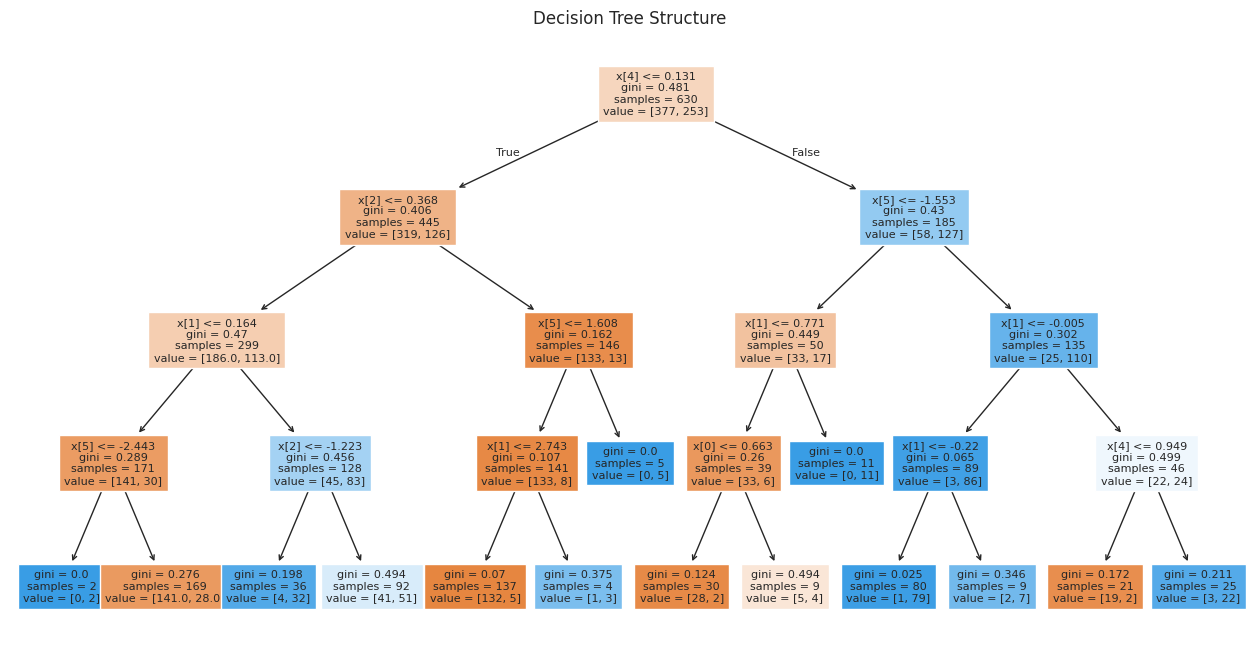

In [4]:
tree=DecisionTreeClassifier(max_depth=4,random_state=42)
tree.fit(X_train,y_train)
plt.figure(figsize=(16,8))
plot_tree(tree,filled=True,fontsize=8)
plt.title('Decision Tree Structure')
plt.show()

## 3. Compare Core Models

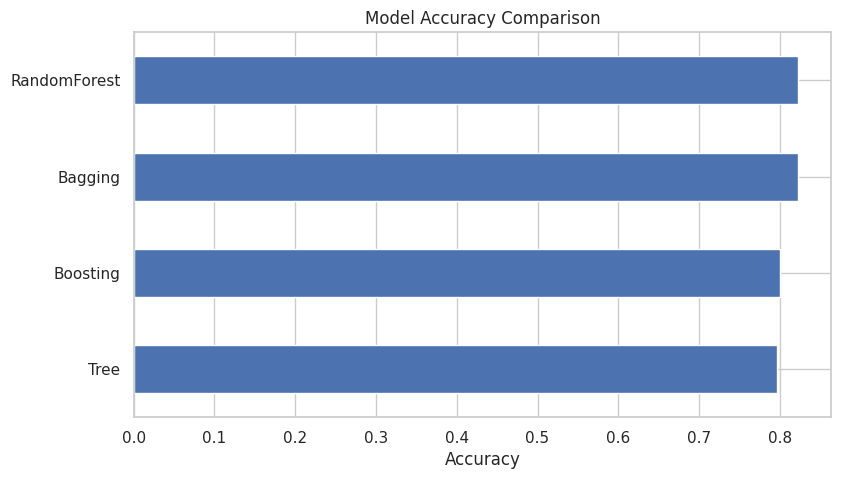

In [5]:
models={
'Tree':DecisionTreeClassifier(max_depth=5,random_state=42),
'Bagging':BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=50,random_state=42),
'RandomForest':RandomForestClassifier(n_estimators=120,random_state=42),
'Boosting':GradientBoostingClassifier(random_state=42)
}
acc={}
for n,m in models.items():
    m.fit(X_train,y_train)
    acc[n]=accuracy_score(y_test,m.predict(X_test))
pd.Series(acc).sort_values().plot(kind='barh',figsize=(9,5),title='Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.show()

## 4. Random Forest Feature Importance
Ensemble trees estimate which variables contribute most.

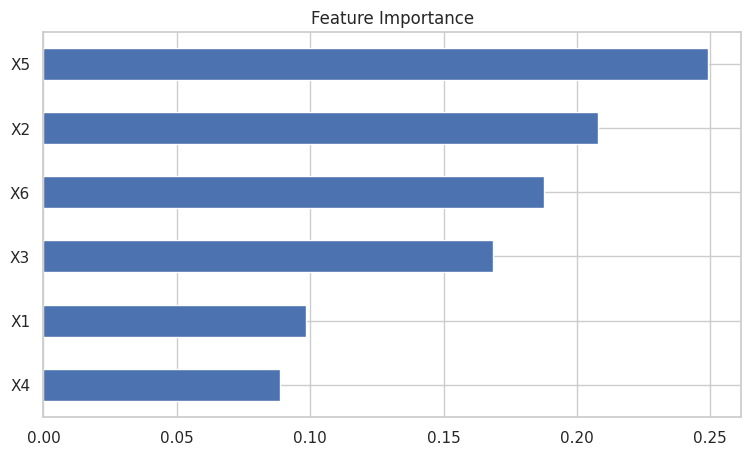

In [6]:
rf=RandomForestClassifier(n_estimators=150,random_state=42).fit(X_train,y_train)
imp=pd.Series(rf.feature_importances_,index=[f'X{i+1}' for i in range(X.shape[1])]).sort_values()
imp.plot(kind='barh',figsize=(9,5),title='Feature Importance')
plt.show()

## 5. Bagging vs Single Tree
Bagging averages many trees to reduce variance.

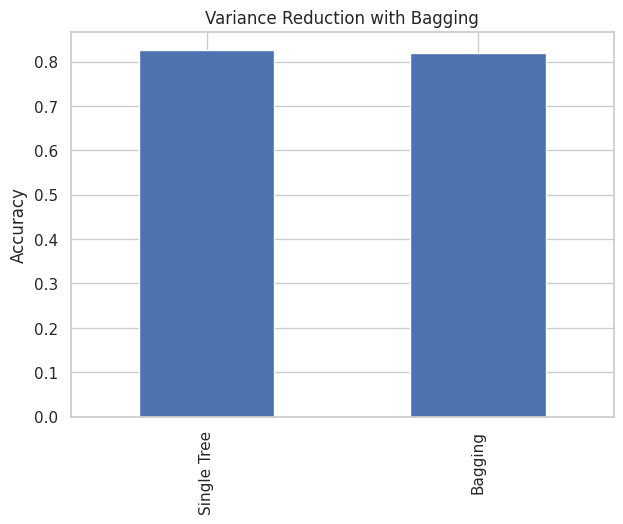

In [7]:
single=DecisionTreeClassifier(random_state=42).fit(X_train,y_train)
bag=BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=80,random_state=42).fit(X_train,y_train)
vals=pd.Series({
'Single Tree':accuracy_score(y_test,single.predict(X_test)),
'Bagging':accuracy_score(y_test,bag.predict(X_test))
})
vals.plot(kind='bar',figsize=(7,5),title='Variance Reduction with Bagging')
plt.ylabel('Accuracy')
plt.show()

## 6. Boosting Concept
Boosting learns sequentially from prior mistakes.

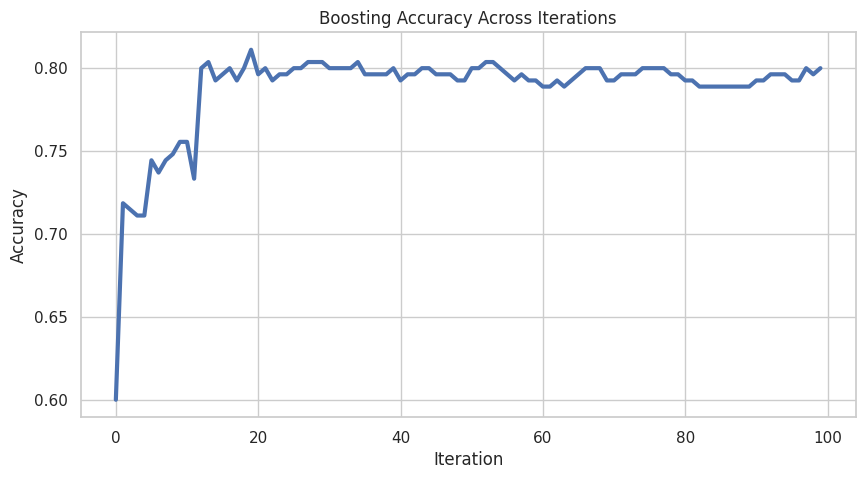

In [8]:
gb=GradientBoostingClassifier(random_state=42).fit(X_train,y_train)
stages=[]
for p in gb.staged_predict(X_test):
    stages.append(accuracy_score(y_test,p))
plt.figure(figsize=(10,5))
plt.plot(stages,lw=3)
plt.title('Boosting Accuracy Across Iterations')
plt.xlabel('Iteration'); plt.ylabel('Accuracy')
plt.show()

## Key Concepts
- Bias-variance tradeoff matters.
- Trees capture nonlinear interactions.
- Bagging reduces variance.
- Random forest adds feature randomness.
- Boosting reduces bias by sequential learning.
- Cross-validation should guide hyperparameters.

## Key Takeaways
1. Start with interpretable baselines.
2. Ensembles often outperform single models.
3. Scaling is crucial for KNN.
4. Feature importance aids explanation.
5. Tune complexity to avoid overfitting.